In [1]:
import networkx as nx
from networkx.readwrite import json_graph
from gerrychain import Graph
import matplotlib.pyplot as plt
import requests
import json
import maup
import geopandas as gpd

In [2]:
blocks = gpd.read_file("./nc_2024_gen_2020_blocks/nc_2024_gen_2020_blocks/nc_2024_gen_2020_blocks.shp")

In [3]:
list(blocks.columns)

['GEOID20',
 'STATEFP',
 'COUNTYFP',
 'PRECINCTID',
 'VAP_MOD',
 'G24PRECTER',
 'G24PREDHAR',
 'G24PREGSTE',
 'G24PREJWES',
 'G24PRELOLI',
 'G24PRENAYY',
 'G24PRENDEL',
 'G24PREOWRI',
 'G24PRERTRU',
 'G24ACVNO',
 'G24ACVYES',
 'G24ATGDJAC',
 'G24ATGRBIS',
 'G24AUDDHOL',
 'G24AUDLDRA',
 'G24AUDRBOL',
 'G24COADTAB',
 'G24COALHAU',
 'G24COARTRO',
 'G24COIDMAR',
 'G24COIRCAU',
 'G24COLDWIN',
 'G24COLRFAR',
 'G24GOVCSMI',
 'G24GOVDSTE',
 'G24GOVGTUR',
 'G24GOVLROS',
 'G24GOVRROB',
 'G24LTGCJON',
 'G24LTGDHUN',
 'G24LTGLBRA',
 'G24LTGRWEA',
 'G24SOSDMAR',
 'G24SOSRBRO',
 'G24SPIDGRE',
 'G24SPIRMOR',
 'G24TREDHAR',
 'G24TRERBRI',
 'GCAJ12DTHO',
 'GCAJ12RMUR',
 'GCAJ14DELD',
 'GCAJ14RZAC',
 'GCAJ15DMOO',
 'GCAJ15RFRE',
 'GSCJ06DRIG',
 'GSCJ06RGRI',
 'GCON01DDAV',
 'GCON01LBAI',
 'GCON01RBUC',
 'GCON02DROS',
 'GCON02GDUB',
 'GCON02RSWA',
 'GCON03LCOR',
 'GCON03RMUR',
 'GCON04DFOU',
 'GCON04LMEI',
 'GCON04RBLA',
 'GCON05DHUB',
 'GCON05RFOX',
 'GCON06CHAY',
 'GCON06RMCD',
 'GCON07DPRI',
 'GCON07R

In [4]:
block_pop = gpd.read_file("./nc_pl2020_b/nc_pl2020_p2_b.shp")

In [5]:
block_pop['Total'] = block_pop['P0020001']
block_pop['Hispanic'] = block_pop['P0020002']
block_pop['NH_White'] = block_pop['P0020005']
# NH_Black captures all census respondents that indicated Black as any of their race selections
block_pop['NH_Black'] = block_pop['P0020006'] + block_pop['P0020013'] + block_pop['P0020018'] + block_pop['P0020019'] + block_pop['P0020020'] + block_pop['P0020021'] + block_pop['P0020029'] + block_pop['P0020030'] + block_pop['P0020031'] + block_pop['P0020032'] + block_pop['P0020039'] + block_pop['P0020040'] + block_pop['P0020041'] + block_pop['P0020042'] + block_pop['P0020043'] + block_pop['P0020044'] + block_pop['P0020050'] + block_pop['P0020051'] + block_pop['P0020052'] + block_pop['P0020053'] + block_pop['P0020054'] + block_pop['P0020055'] + block_pop['P0020060'] + block_pop['P0020061'] + block_pop['P0020062'] + block_pop['P0020063'] + block_pop['P0020066'] + block_pop['P0020067'] + block_pop['P0020068'] + block_pop['P0020069'] + block_pop['P0020071'] + block_pop['P0020073']
block_pop['NH_Other'] = block_pop['Total'] - block_pop['Hispanic'] - block_pop['NH_White'] - block_pop['NH_Black']

In [6]:
# VAP Demographics
block_pop_vap = gpd.read_file("./nc_pl2020_b/nc_pl2020_p4_b.shp")

In [7]:
block_pop_vap['Total_VAP'] = block_pop_vap['P0040001']
block_pop_vap['Hispanic_VAP'] = block_pop_vap['P0040002']
block_pop_vap['NH_White_VAP'] = block_pop_vap['P0040005']
# NH_Black captures all census respondents that indicated Black as any of their race selections
block_pop_vap['NH_Black_VAP'] = block_pop_vap['P0040006'] + block_pop_vap['P0040013'] + block_pop_vap['P0040018'] + block_pop_vap['P0040019'] + block_pop_vap['P0040020'] + block_pop_vap['P0040021'] + block_pop_vap['P0040029'] + block_pop_vap['P0040030'] + block_pop_vap['P0040031'] + block_pop_vap['P0040032'] + block_pop_vap['P0040039'] + block_pop_vap['P0040040'] + block_pop_vap['P0040041'] + block_pop_vap['P0040042'] + block_pop_vap['P0040043'] + block_pop_vap['P0040044'] + block_pop_vap['P0040050'] + block_pop_vap['P0040051'] + block_pop_vap['P0040052'] + block_pop_vap['P0040053'] + block_pop_vap['P0040054'] + block_pop_vap['P0040055'] + block_pop_vap['P0040060'] + block_pop_vap['P0040061'] + block_pop_vap['P0040062'] + block_pop_vap['P0040063'] + block_pop_vap['P0040066'] + block_pop_vap['P0040067'] + block_pop_vap['P0040068'] + block_pop_vap['P0040069'] + block_pop_vap['P0040071'] + block_pop_vap['P0040073']
block_pop_vap['NH_Other_VAP'] = block_pop_vap['Total_VAP'] - block_pop_vap['Hispanic_VAP'] - block_pop_vap['NH_White_VAP'] - block_pop_vap['NH_Black_VAP']

In [8]:
blocks_w_pop = blocks.merge(block_pop[['GEOID20','Total','Hispanic','NH_White','NH_Black','NH_Other']].set_index('GEOID20'),on="GEOID20")
blocks_w_pop = blocks_w_pop.merge(block_pop_vap[['GEOID20','Total_VAP','Hispanic_VAP','NH_White_VAP','NH_Black_VAP','NH_Other_VAP']].set_index('GEOID20'),on="GEOID20")

In [9]:
blocks_w_pop['population'] = blocks_w_pop['Total']
blocks_w_pop['population_vap'] = blocks_w_pop['Total_VAP']

In [10]:
blocks_w_pop.head()

,GEOID20,STATEFP,COUNTYFP,PRECINCTID,VAP_MOD,G24PRECTER,G24PREDHAR,G24PREGSTE,G24PREJWES,G24PRELOLI,...,NH_White,NH_Black,NH_Other,Total_VAP,Hispanic_VAP,NH_White_VAP,NH_Black_VAP,NH_Other_VAP,population,population_vap
0,370010201001000,37,1,ALAMANCE-:-12W,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,370010201001001,37,1,ALAMANCE-:-12W,23,0,9,0,0,0,...,28,5,0,23,0,18,5,0,34,23
2,370010201001002,37,1,ALAMANCE-:-12W,22,0,8,0,0,0,...,14,9,2,22,3,9,8,2,30,22
3,370010201001003,37,1,ALAMANCE-:-12W,25,0,9,0,0,0,...,19,3,2,25,2,18,3,2,34,25
4,370010201001004,37,1,ALAMANCE-:-12W,47,0,17,0,0,0,...,34,17,0,47,9,24,14,0,60,47


In [11]:
CON = gpd.read_file("./nc_cong_adopted_2025/NCGA_CCM-2 - Shapefile/CCM-2.shp")
SLDU = gpd.read_file("./nc_sldu_adopted_2023/SL 2023-146 Senate - Shapefile/SL 2023-146.shp")
SLDL = gpd.read_file("./nc_sldl_adopted_2023/SL 2023-149 House - Shapefile/SL 2023-149.shp")

In [12]:
CON = CON.to_crs(blocks_w_pop.crs)
SLDU = SLDU.to_crs(blocks_w_pop.crs)
SLDL = SLDL.to_crs(blocks_w_pop.crs)


bk_to_CON = maup.assign(blocks_w_pop,CON)
bk_to_SLDU = maup.assign(blocks_w_pop,SLDU.to_crs(blocks_w_pop.crs))
bk_to_SLDL = maup.assign(blocks_w_pop,SLDL.to_crs(blocks_w_pop.crs))

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df = df[df.area > area_cutoff].reset_index(drop=True)
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometries = geometries[geometries.area > area_cutoff]
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\assign.py:38: UserWarning: Geometry is in a geograp

In [13]:
blocks_w_pop["CON"] = bk_to_CON
blocks_w_pop["SLDU"] = bk_to_SLDU
blocks_w_pop["SLDL"] = bk_to_SLDL

In [14]:
SLDL.head()

,DISTRICT,PL20AA_TOT,geometry
0,1,82812,"POLYGON ((-76.31330 36.55052, -76.28859 36.550..."
1,10,83014,"POLYGON ((-77.82251 35.58538, -77.82263 35.580..."
2,100,86763,"POLYGON ((-80.67010 35.20839, -80.67011 35.207..."
3,101,84368,"POLYGON ((-80.81972 35.36387, -80.81982 35.363..."
4,102,84206,"POLYGON ((-80.77015 35.19880, -80.77034 35.198..."


(-84.7679061, -74.9540339, 33.61111505, 36.729899950000004)

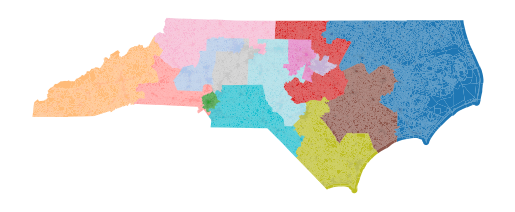

In [15]:
blocks_w_pop.plot(column="CON",cmap='tab20')
plt.axis('off')

In [16]:
precincts = blocks_w_pop[["PRECINCTID","geometry"]].dissolve(by="PRECINCTID")

In [17]:
precincts_w_pop = precincts.merge(blocks_w_pop.groupby("PRECINCTID")[['population','population_vap','G24PRERTRU','G24PREDHAR','G24GOVDSTE','G24GOVRROB','Total','Hispanic','NH_White','NH_Black','NH_Other','Total_VAP','Hispanic_VAP','NH_White_VAP','NH_Black_VAP','NH_Other_VAP']].sum(),on="PRECINCTID")

In [18]:
precincts_w_pop=precincts_w_pop.merge(blocks_w_pop.groupby("PRECINCTID")["COUNTYFP"].max(),on="PRECINCTID")

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df = df[df.area > area_cutoff].reset_index(drop=True)
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometries = geometries[geometries.area > area_cutoff]
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\assign.py:38: UserWarning: Geometry is in a geograp

(-84.7679061, -74.9540339, 33.61111505, 36.729899950000004)

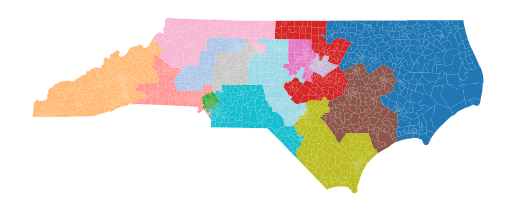

In [19]:
SLDL.set_index('DISTRICT',inplace=True)

p_to_CON = maup.assign(precincts_w_pop,CON)
p_to_SLDU = maup.assign(precincts_w_pop,SLDU.to_crs(precincts_w_pop.crs))
p_to_SLDL = maup.assign(precincts_w_pop,SLDL.to_crs(precincts_w_pop.crs))



precincts_w_pop["CON"] = p_to_CON
precincts_w_pop["SLDU"] = p_to_SLDU
precincts_w_pop["SLDL"] = p_to_SLDL

precincts_w_pop.plot(column="CON",cmap='tab20')
plt.axis('off')

In [20]:
precincts_w_pop['C_X'] = precincts_w_pop.centroid.x
precincts_w_pop['C_Y'] = precincts_w_pop.centroid.y
blocks_w_pop['C_X'] = blocks_w_pop.centroid.x
blocks_w_pop['C_Y'] = blocks_w_pop.centroid.y

C:\Users\angel\AppData\Local\Temp\ipykernel_8232\603903982.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  precincts_w_pop['C_X'] = precincts_w_pop.centroid.x
C:\Users\angel\AppData\Local\Temp\ipykernel_8232\603903982.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  precincts_w_pop['C_Y'] = precincts_w_pop.centroid.y
C:\Users\angel\AppData\Local\Temp\ipykernel_8232\603903982.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_w_pop['C_X'] = blocks_w_pop.centroid.x
C:\Users\angel\AppData\Local\Temp\ipykernel_8232\603903982.py:4: UserWarning: Geometry is in a

In [ ]:
precinct_graph = Graph.from_geodataframe(precincts_w_pop)


precincts_w_pop.to_file("./output/NC_Processed_Precincts.shp")

precinct_graph.to_json("./output/NC_Processed_Precincts.json")

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:266: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = df.geometry.area.to_dict()
C:\Users\angel\AppData\Local\Temp\ipykernel_8232\3131046038.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  precincts_w_pop.to_file("./NC_Processed_Precincts.shp")
